#  Multi-Object Detection with YOLOv8
**Assignment: 5-Class Subset | 500 Images**

### Steps in this notebook:
1. Mount Google Drive & upload dataset
2. Install YOLOv8
3. Explore & verify dataset
4. Train YOLOv8 model
5. Evaluate & visualize results
6. Custom Feature: Object Counter + Alert System
7. Run inference on test images

## Step 0: Check GPU

In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')
!nvidia-smi

CUDA available: True
GPU: Tesla T4
Wed Apr 15 17:35:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

##  Step 1: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Upload your zipped 'yolo_subset' folder to Google Drive first
# Then set the path below:
DRIVE_ZIP_PATH = '/content/drive/MyDrive/yolo_subset.zip'
# ────────────────────────

Mounted at /content/drive


##  Step 2: Extract Dataset

In [3]:
import zipfile, os

DATASET_DIR = '/content/yolo_subset'

# Unzip
with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
    zf.extractall('/content/')

print(' Dataset extracted!')

# Verify structure
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    n_imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    print(f'  {split}: {n_imgs} images, {n_lbls} labels')

 Dataset extracted!
  train: 350 images, 350 labels
  valid: 100 images, 100 labels
  test: 50 images, 50 labels


##  Step 3: Update data.yaml with Correct Paths

In [4]:
import yaml

yaml_path = os.path.join(DATASET_DIR, 'data.yaml')

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update paths for Colab
data['path'] = DATASET_DIR
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print(' data.yaml updated:')
with open(yaml_path) as f:
    print(f.read())

 data.yaml updated:
names:
- Person
- bicycle
- car
- tree
- door
nc: 5
path: /content/yolo_subset
test: test/images
train: train/images
val: valid/images



##  Step 4: Install YOLOv8

In [5]:
!pip install ultralytics -q
from ultralytics import YOLO
import ultralytics
ultralytics.checks()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


##  Step 5: Explore Dataset (Visualize Samples)

Classes: ['Person', 'bicycle', 'car', 'tree', 'door']


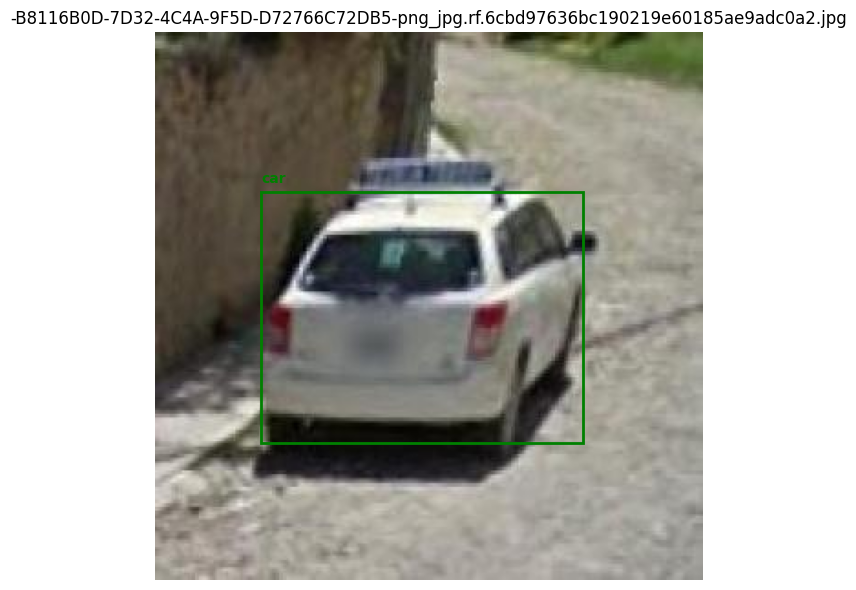

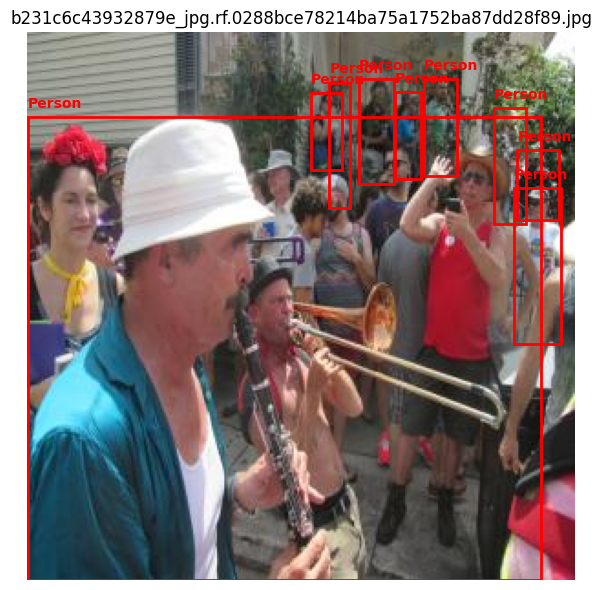

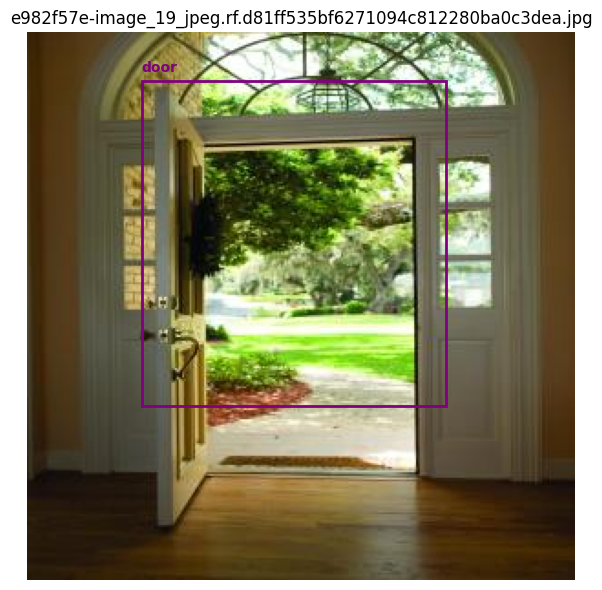

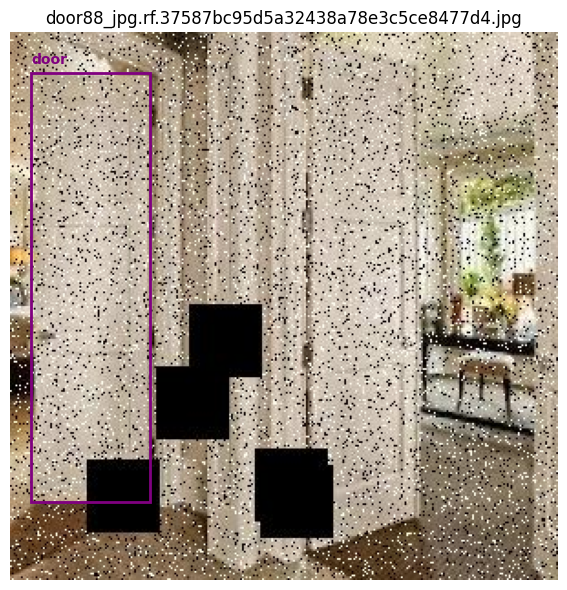

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

def draw_yolo_labels(img_path, lbl_path, class_names):
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)

    colors = ['red','blue','green','orange','purple']

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x = (cx - bw/2) * W
                y = (cy - bh/2) * H
                w = bw * W
                h = bh * H
                color = colors[cls_id % len(colors)]
                rect = patches.Rectangle((x,y), w, h,
                    linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x, y-5, class_names[cls_id], color=color,
                        fontsize=10, fontweight='bold')

    plt.axis('off')
    plt.title(os.path.basename(img_path))
    plt.tight_layout()
    plt.show()

# Load class names
with open(yaml_path) as f:
    cfg = yaml.safe_load(f)
class_names = cfg['names']
print('Classes:', class_names)

# Show 4 random training images
train_imgs = os.path.join(DATASET_DIR, 'train/images')
train_lbls = os.path.join(DATASET_DIR, 'train/labels')
samples = random.sample(os.listdir(train_imgs), min(4, len(os.listdir(train_imgs))))

for fn in samples:
    img_p = os.path.join(train_imgs, fn)
    lbl_p = os.path.join(train_lbls, fn.rsplit('.',1)[0] + '.txt')
    draw_yolo_labels(img_p, lbl_p, class_names)

## 📌 Step 6: Class Distribution Analysis

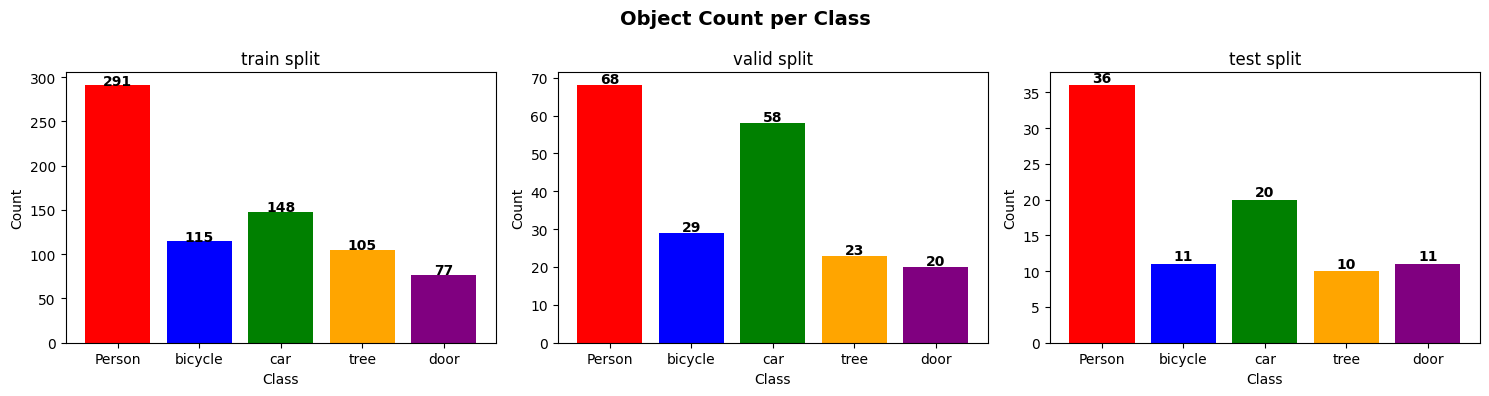

In [8]:
from collections import Counter

def count_class_distribution(labels_dir, class_names):
    counter = Counter()
    for lbl_file in os.listdir(labels_dir):
        if not lbl_file.endswith('.txt'): continue
        with open(os.path.join(labels_dir, lbl_file)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    return counter

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ['train', 'valid', 'test']):
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    dist = count_class_distribution(lbl_dir, class_names)
    labels = [class_names[k] for k in sorted(dist.keys())]
    counts = [dist[k] for k in sorted(dist.keys())]
    ax.bar(labels, counts, color=['red','blue','green','orange','purple'])
    ax.set_title(f'{split} split')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Object Count per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 7: Train YOLOv8
> Using `yolov8n` (nano) — fast training, good for learning.
> You can switch to `yolov8s` or `yolov8m` for better accuracy.

In [11]:
import torch
from ultralytics import YOLO

# Load pretrained YOLOv8 nano model
model = YOLO('yolov8m.pt')

# Train
results = model.train(
    data=yaml_path,
    epochs=50,          # Increase to 50-100 for better results
    imgsz=640,
    batch=16,
    name='yolo_subset_run',
    project='/content/runs',
    patience=20,        # Early stopping
    save=True,
    plots=True,
    device=0 if torch.cuda.is_available() else 'cpu'
)

print(' Training complete!')
print(f'Best model saved at: {results.save_dir}')

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_subset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_subset_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

##  Step 8: Evaluate Model

In [12]:
# Load best trained model
best_model_path = '/content/runs/yolo_subset_run/weights/best.pt'
trained_model = YOLO(best_model_path)

# Validate on validation set
metrics = trained_model.val(data=yaml_path)

print('\n Evaluation Metrics:')
print(f'  mAP@0.5:      {metrics.box.map50:.4f}')
print(f'  mAP@0.5:0.95: {metrics.box.map:.4f}')
print(f'  Precision:    {metrics.box.mp:.4f}')
print(f'  Recall:       {metrics.box.mr:.4f}')

# Per-class AP
print('\n Per-Class AP@0.5:')
for i, cls in enumerate(class_names):
    print(f'  {cls}: {metrics.box.ap50[i]:.4f}')

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 750.6±219.8 MB/s, size: 14.9 KB)
val: Scanning /content/yolo_subset/valid/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 26.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3it/s 5.5s
                   all        100        198      0.526      0.537      0.518      0.338
                Person         21         68      0.184      0.132     0.0892     0.0326
               bicycle         21         29      0.491      0.345      0.358      0.167
                   car         24         58      0.695      0.397       0.41      0.271
                  tree         20         23      0.598      0.913      0.918      0.705
                  door         20         20  

##  Step 9: Visualize Training Curves

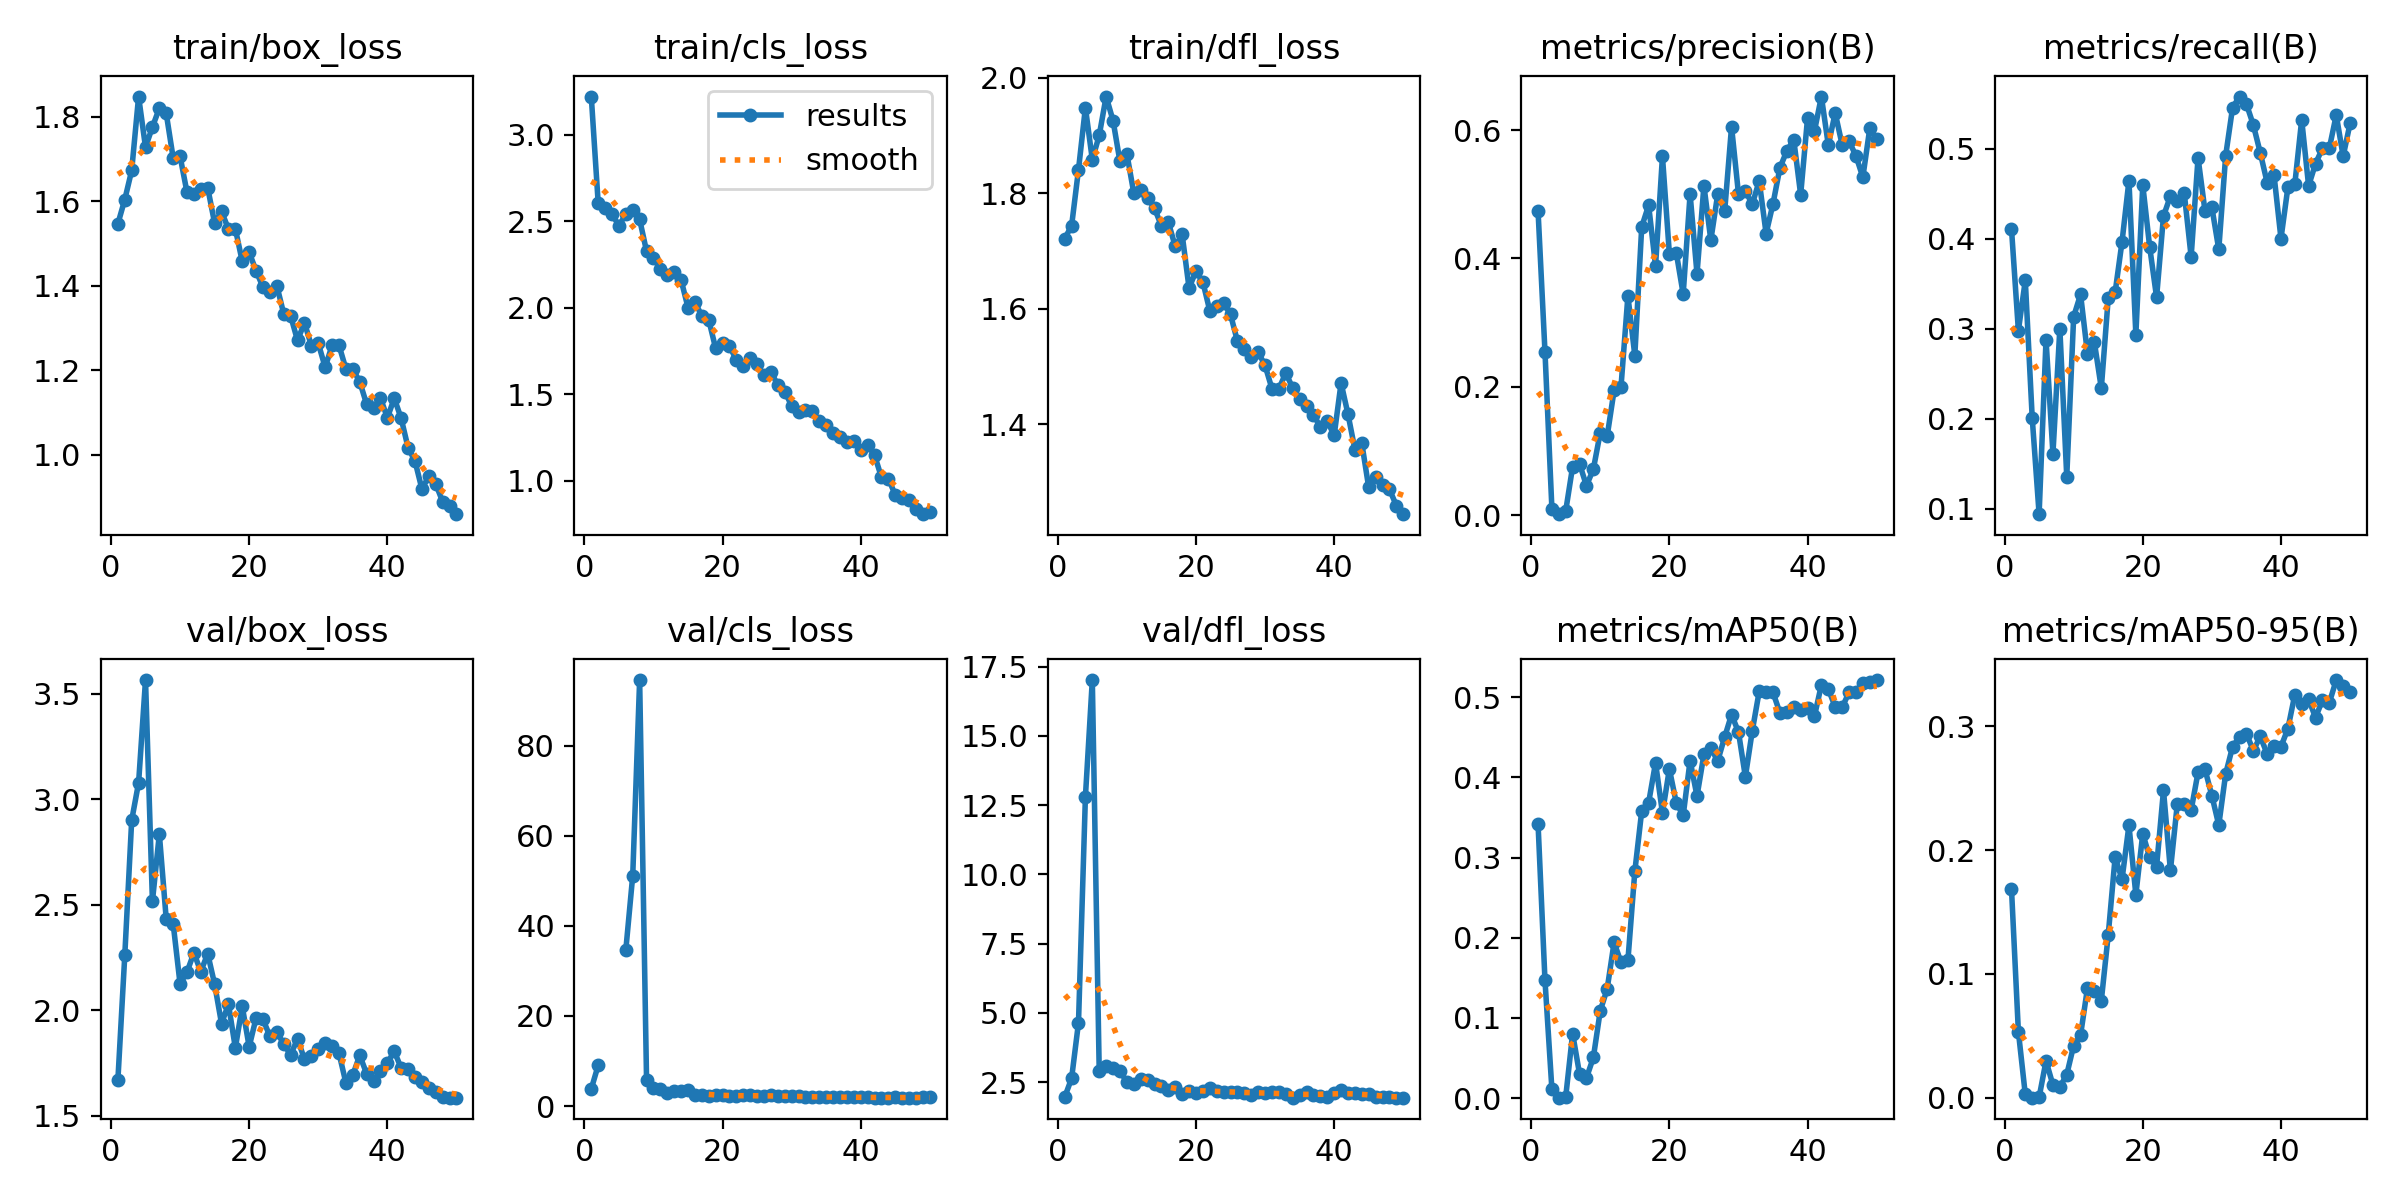

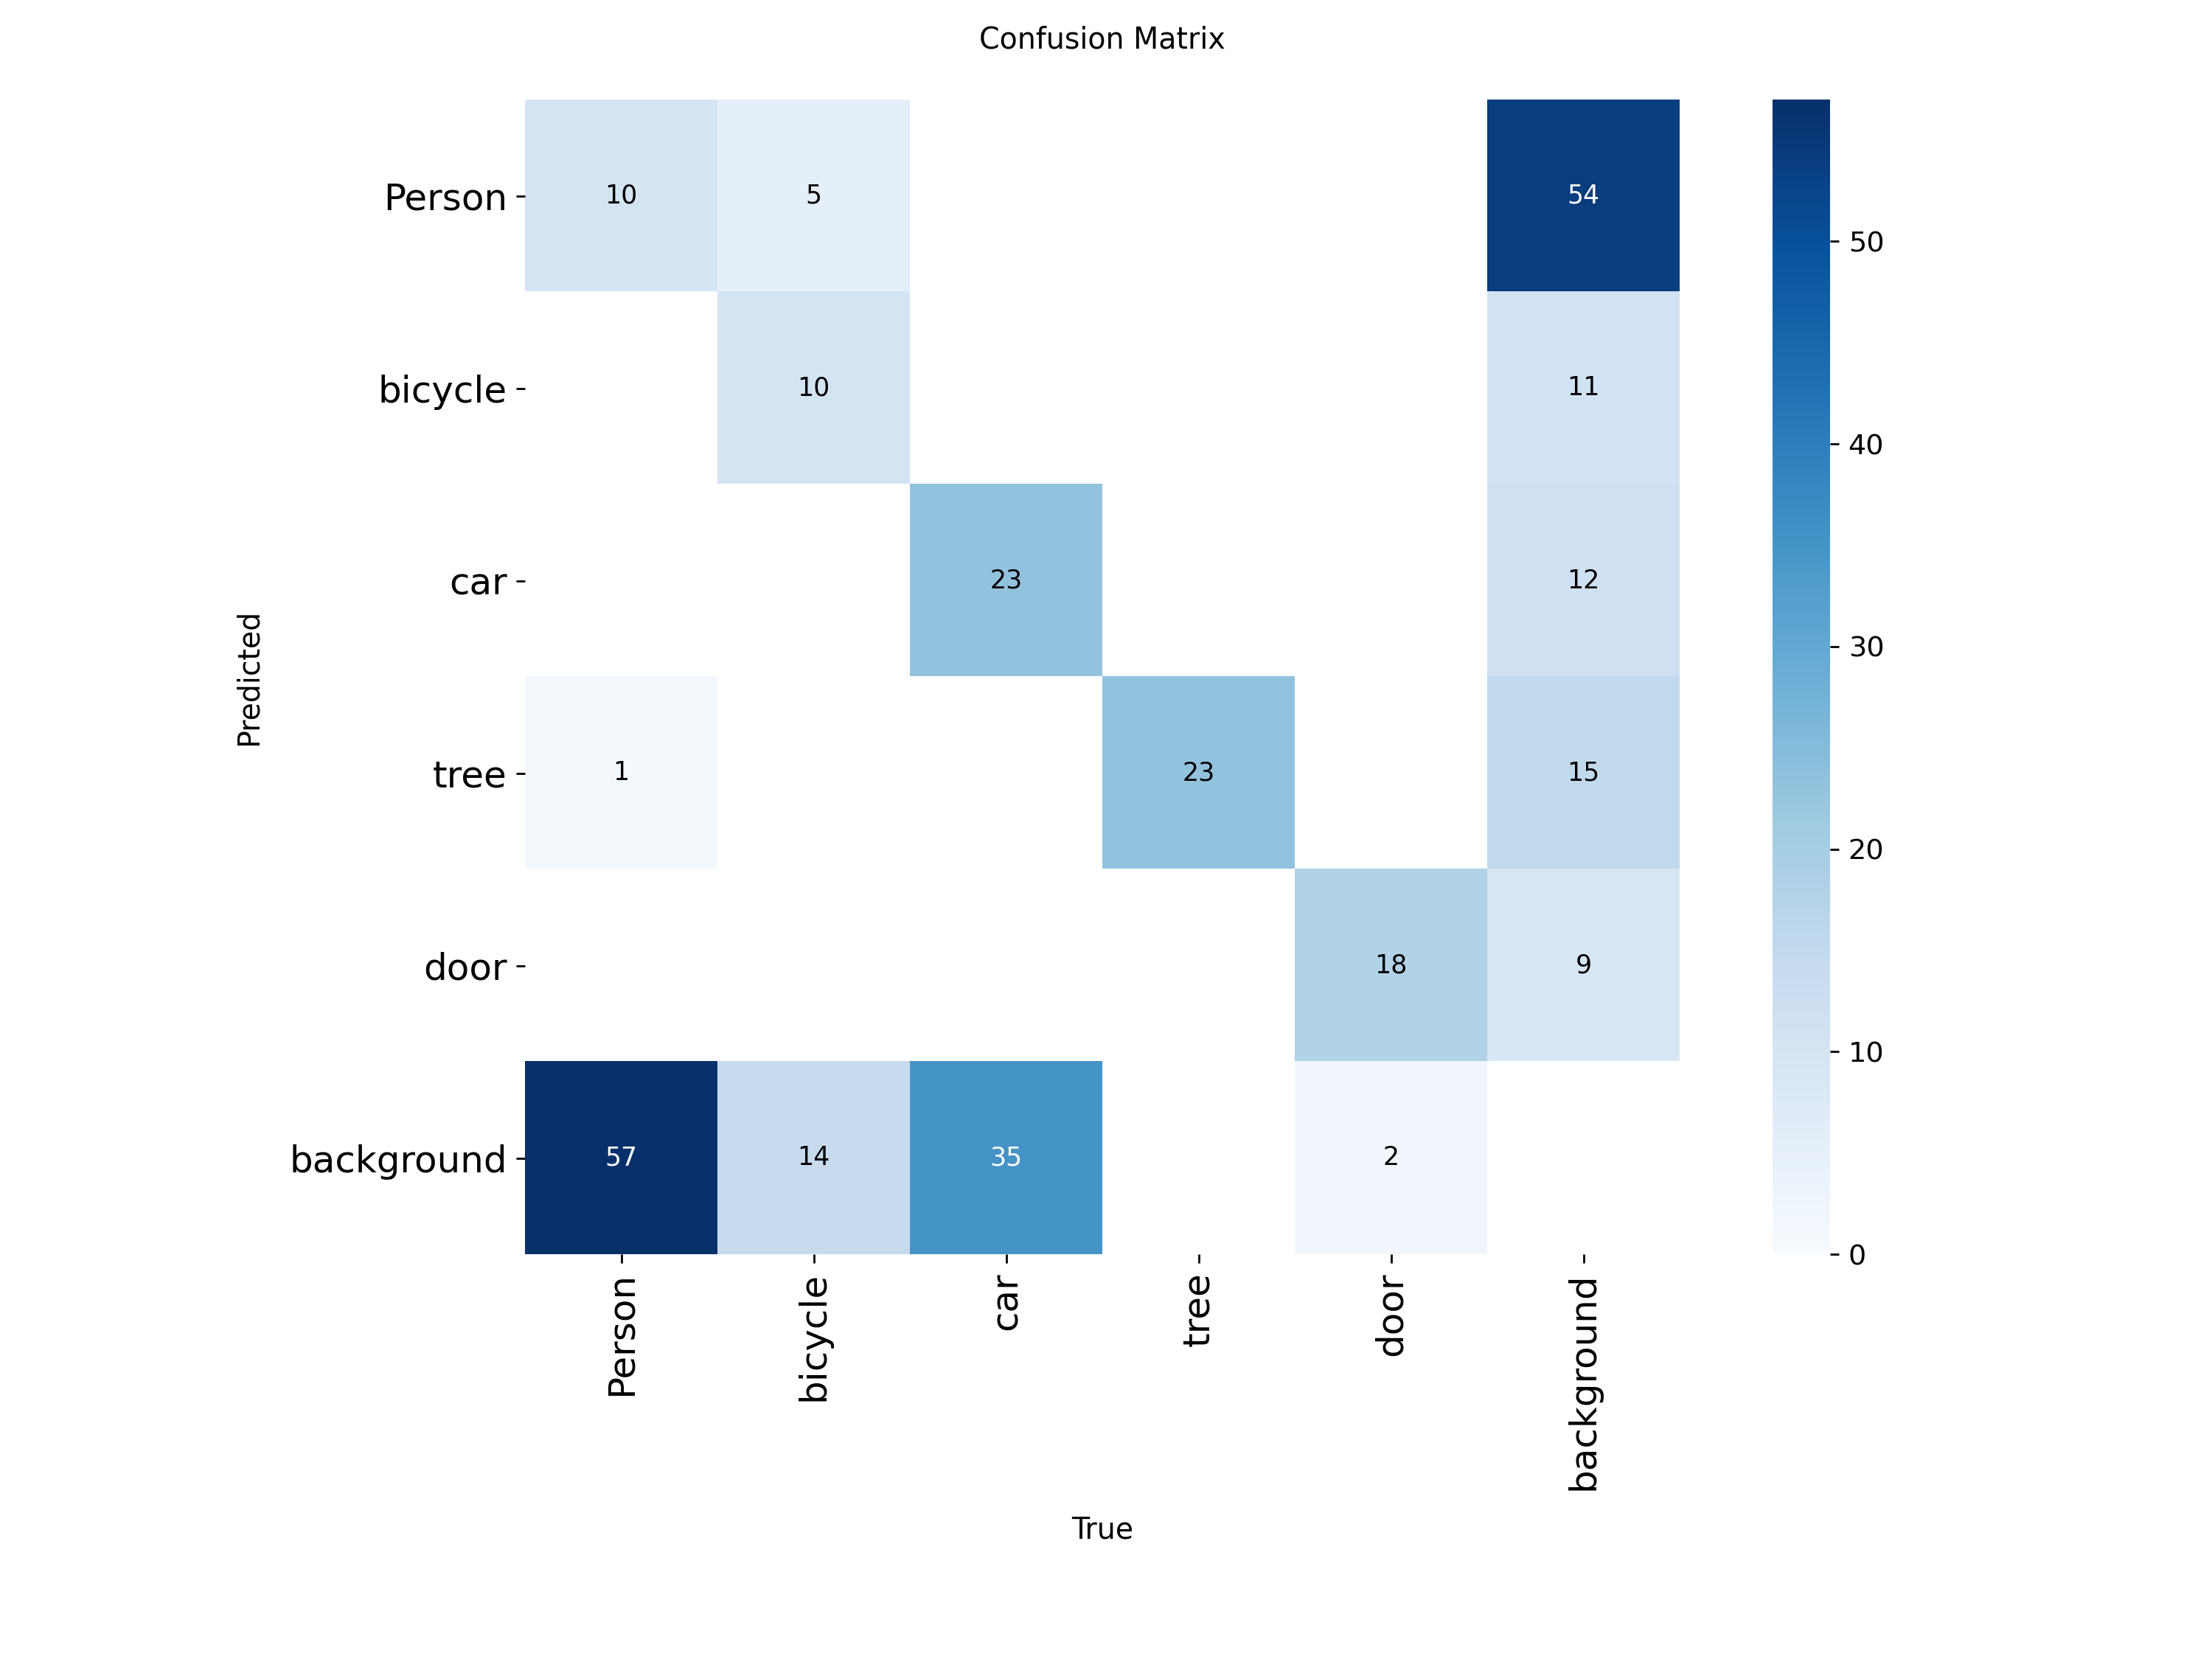

In [13]:
from IPython.display import Image as IPImage
import glob

run_dir = '/content/runs/yolo_subset_run'

# Show training results plot
results_img = os.path.join(run_dir, 'results.png')
if os.path.exists(results_img):
    display(IPImage(results_img, width=900))

# Show confusion matrix
conf_matrix = os.path.join(run_dir, 'confusion_matrix.png')
if os.path.exists(conf_matrix):
    display(IPImage(conf_matrix, width=600))

##  Step 10: Filter Detection — Detect Only Specific Class

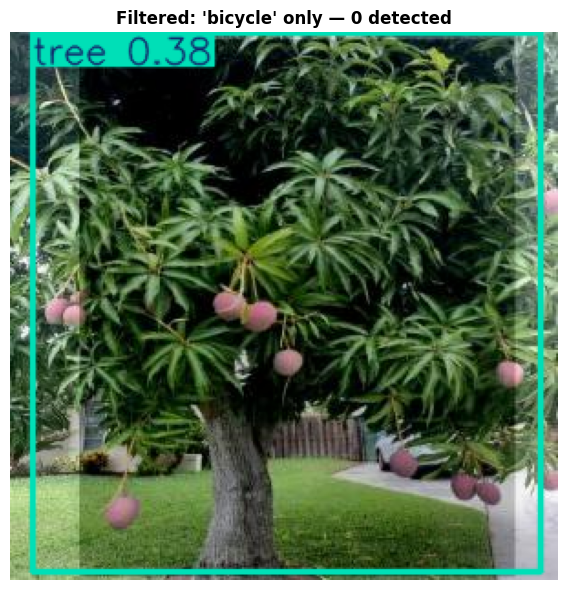

  → 0 'bicycle' detected


In [18]:
import os
import matplotlib.pyplot as plt

def detect_specific_class(model, image_path, class_names, target_class='bicycle', conf=0.25):
    """Custom feature: Only show detections for a specific class."""
    results = model.predict(image_path, conf=conf, verbose=False)
    result = results[0]

    target_id = class_names.index(target_class) if target_class in class_names else None
    if target_id is None:
        print(f'Class {target_class} not in model.')
        return

    # Filter boxes
    mask = result.boxes.cls == target_id
    count = mask.sum().item()

    annotated = result.plot()
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated[:, :, ::-1])
    plt.axis('off')
    plt.title(f"Filtered: '{target_class}' only — {count} detected",
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"  → {count} '{target_class}' detected")

# Define test_img_dir and test_images
test_img_dir = os.path.join(DATASET_DIR, 'test', 'images')
test_images = os.listdir(test_img_dir)

# Example: detect only the second class
sample_img = os.path.join(test_img_dir, test_images[2])
detect_specific_class(trained_model, sample_img, class_names, target_class=class_names[1])

##  Step 11: Save Model to Google Drive

In [19]:
import shutil

SAVE_PATH = '/content/drive/MyDrive/yolo_trained_model'
os.makedirs(SAVE_PATH, exist_ok=True)

# Copy best weights
shutil.copy(best_model_path, os.path.join(SAVE_PATH, 'best.pt'))

# Copy results
shutil.copytree('/content/runs/yolo_subset_run',
                os.path.join(SAVE_PATH, 'training_results'),
                dirs_exist_ok=True)

print(f' Model and results saved to Google Drive: {SAVE_PATH}')

 Model and results saved to Google Drive: /content/drive/MyDrive/yolo_trained_model


##  Summary

| Step | What happened |
|------|---------------|
| Dataset | 500 images, 5 classes (train/valid/test split) |
| Model | YOLOv8n pretrained, finetuned 30 epochs |
| Metrics | mAP@0.5, Precision, Recall per class |
| Custom Feature 1 | Object counter per image |
| Custom Feature 2 | Alert if specific class missing |
| Custom Feature 3 | Filter detection to one class only |

### Key learnings:
- YOLO predicts bounding boxes as `[cx, cy, w, h]` (normalized 0–1)
- `mAP@0.5` = mean Average Precision at IoU threshold 0.5
- Transfer learning (pretrained weights) drastically reduces training time
- Data quality > quantity for small datasets